## Neurônio Perceptron

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Funções para modelar o neurônio

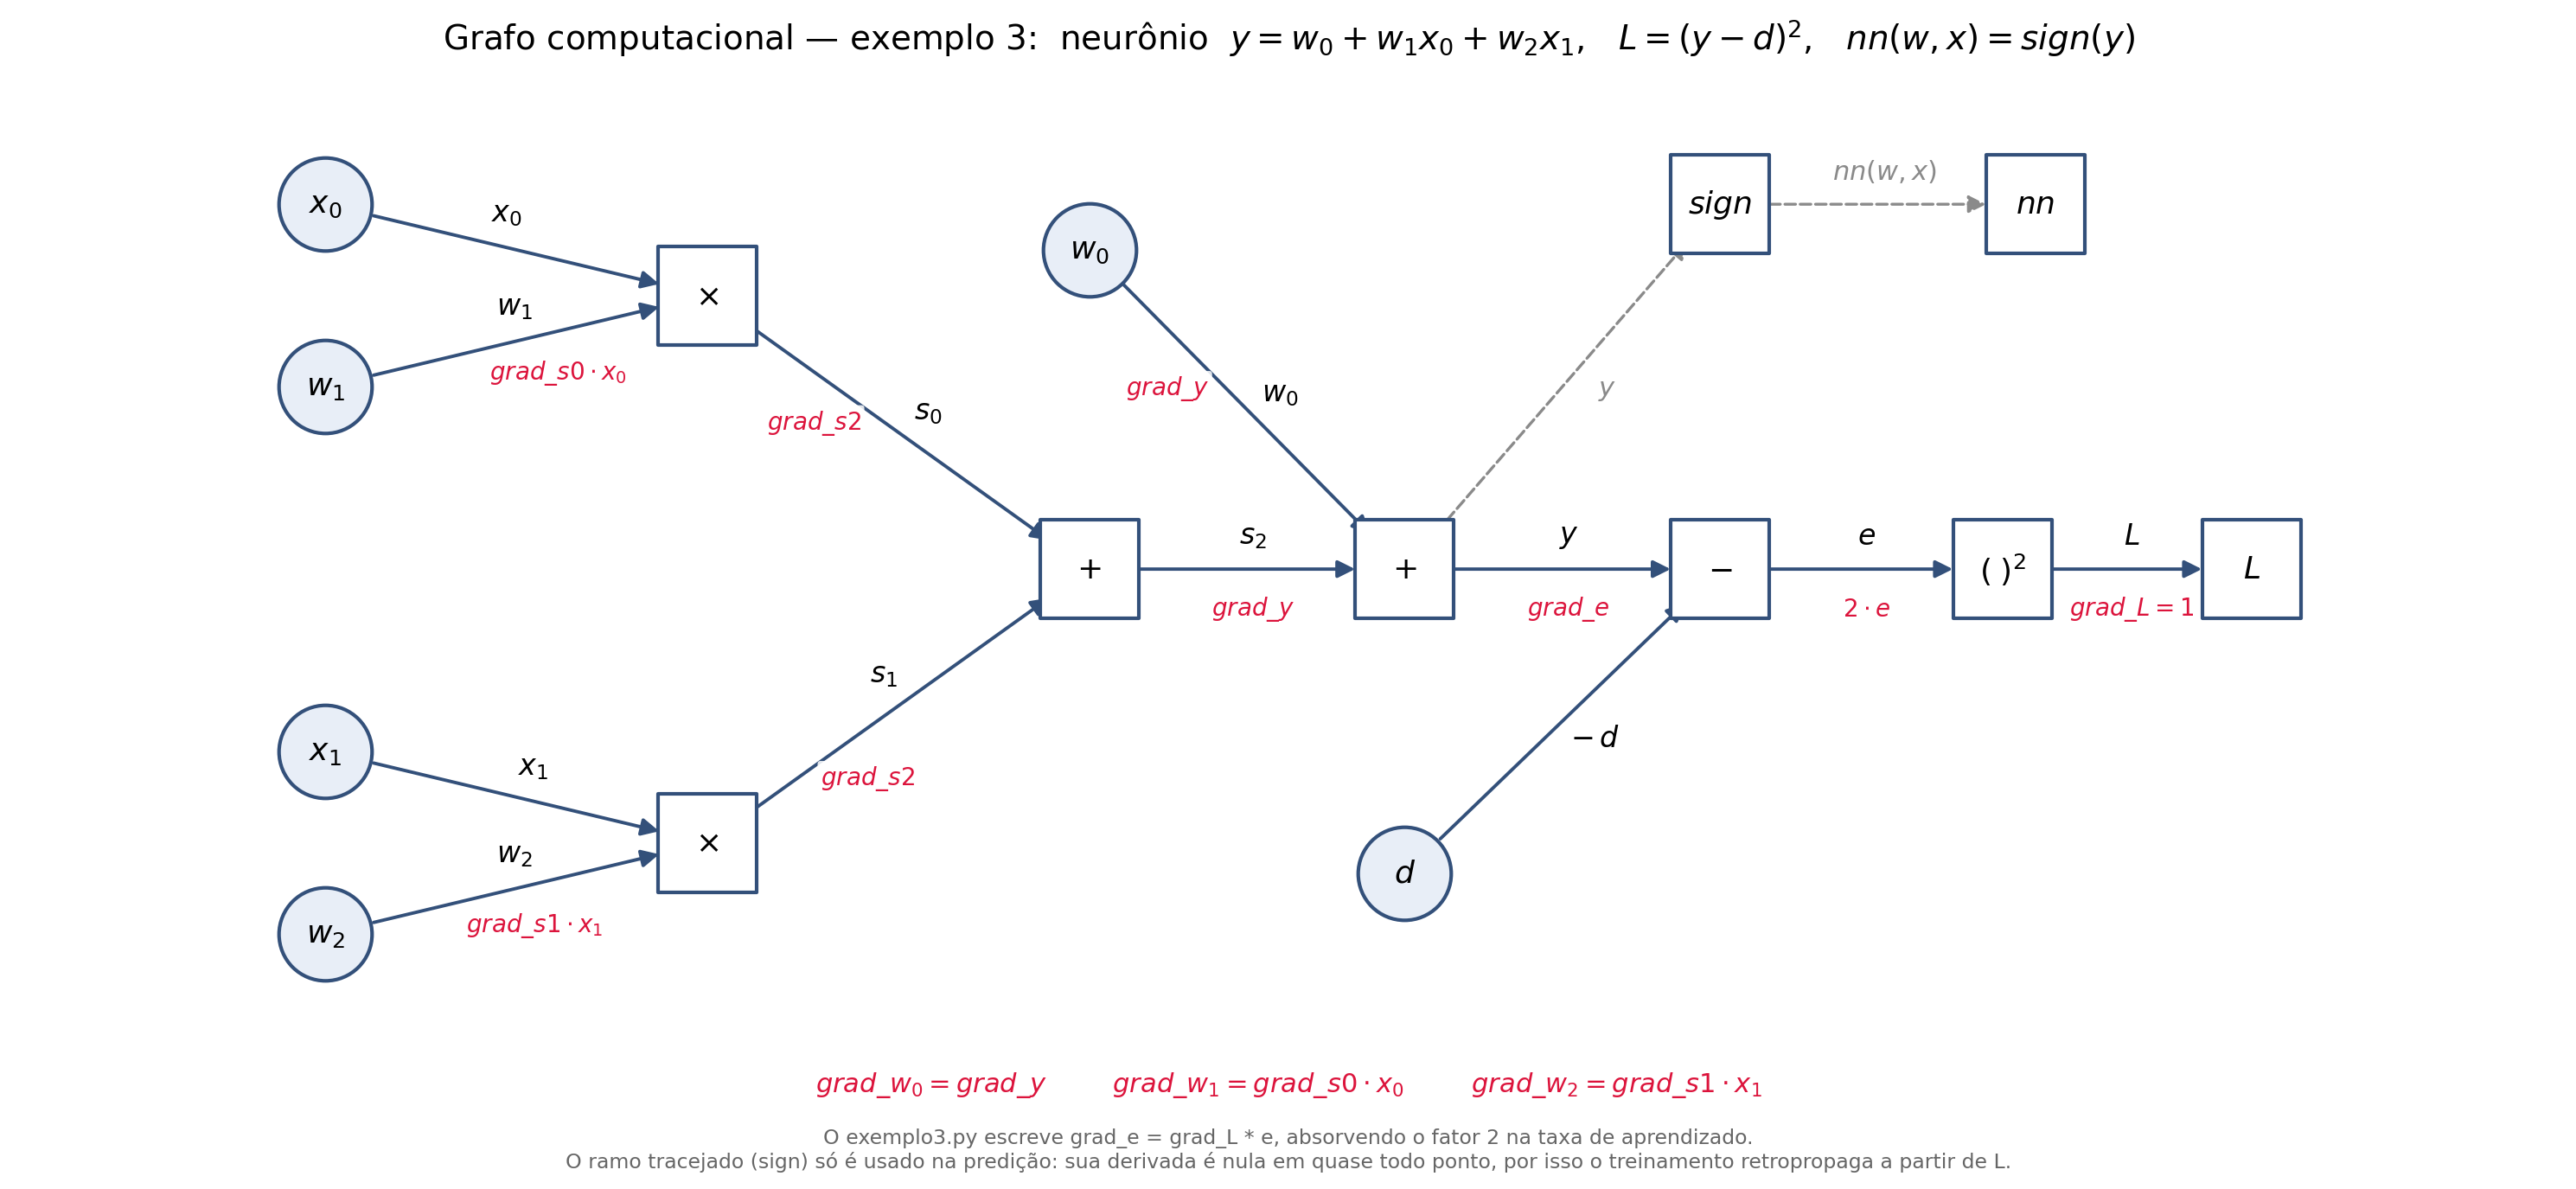

In [6]:
def grad_nn(w, x, d):
    # feedforward
    s0 = w[1] * x[0]
    s1 = w[2] * x[1]
    s2 = s0 + s1
    y = w[0] + s2
    e = y - d
    L = e ** 2

    # backward
    grad_L = 1
    grad_e = grad_L * e
    grad_y = grad_e
    grad_s2 = grad_y
    grad_s1 = grad_s2
    grad_s0 = grad_s2
    grad_w0 = grad_y
    grad_w1 = grad_s0 * x[0]
    grad_w2 = grad_s1 * x[1]

    return np.array([grad_w0, grad_w1, grad_w2])

def nn(w, x):
    return np.sign(w[0] + w[1] * x[0] + w[2] * x[1]) 

0.0
0.0
0.0
0.0

nn[X[0]] :  -1.0 d[0]:  -1.0
nn[X[1]] :  -1.0 d[1]:  -1.0
nn[X[2]] :  -1.0 d[2]:  -1.0
nn[X[3]] :  1.0 d[3]:  1.0


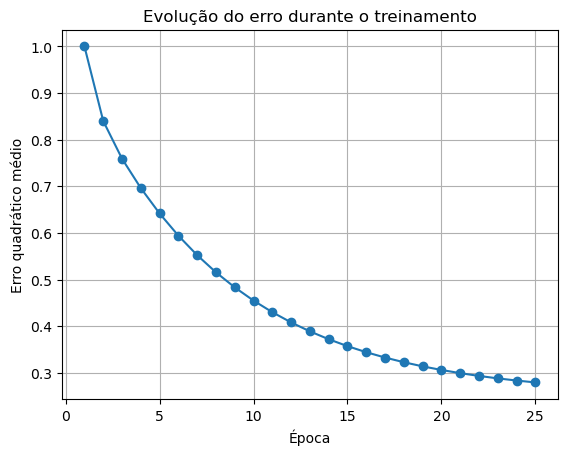

In [ ]:
def main():
    np.random.seed(1)
    # Problema: A porta AND
    X = [[0., 0.], [0., 1.], [1., 0.], [1., 1.]]
    d = [-1., -1., -1., 1.]
    # w = np.random.rand(3)
    w = np.array([0., 0., 0.])
    taxa = 0.1

    # Lista para armazenar o erro de cada época
    historico_erro = []

    print(nn(w, X[0]))
    print(nn(w, X[1]))
    print(nn(w, X[2]))
    print(nn(w, X[3]))
    print()
    for _ in range(25):
        grad_w = np.array([0., 0., 0.])

        # Armazena os erros das 4 amostras desta época
        erros_epoca = []

        for i in range(4):
            grad_w += grad_nn(w, X[i], d[i] )

            # Forward
            y = w[0] + w[1] * X[i][0] + w[2] * X[i][1]
            
            # Erro
            e = y - d[i]

            # Erro quadrático
            erros_epoca.append(e**2)

        # Média dos erros das 4 amostras
        erro_medio = np.mean(erros_epoca)

        # Guarda para posteriormente plotar
        historico_erro.append(erro_medio)

        # Atualização do vetor de pesos
        w -= taxa * grad_w

        # Armazena o erro médio desta época
        #historico_erro.append(np.mean(np.abs(erros_epoca)))

    print('nn[X[0]] : ', nn(w, X[0]), 'd[0]: ', d[0])
    print('nn[X[1]] : ', nn(w, X[1]), 'd[1]: ', d[1])
    print('nn[X[2]] : ', nn(w, X[2]), 'd[2]: ', d[2])
    print('nn[X[3]] : ', nn(w, X[3]), 'd[3]: ', d[3])

    # -------------------------
    # Gráfico da queda do erro
    # -------------------------

    plt.plot(
        range(1, 26),
        historico_erro,
        marker='o'
    )

    plt.xlabel('Época')
    plt.ylabel('Erro quadrático médio')
    plt.title('Evolução do erro durante o treinamento')
    plt.grid()

    plt.show()


main()